# Random Forest Ablation: Plot Interpretation Guide

This notebook is a report-writing aid. It explains what each figure shows, why it matters for the research question, and how to phrase conclusions in a research-paper style.

**Focus:** Conceptual interpretation and decision-making, not implementation detail.

**Research question:** What is the individual and combined impact of bootstrapping and random feature selection on the bias–variance trade-off in regression tree ensembles?

In [3]:
from pathlib import Path
from IPython.display import display, Markdown, Image

PLOT_DIR = Path('result_plots')
print('Using plot directory:', PLOT_DIR.resolve())
print('Available plots:')
for p in sorted(PLOT_DIR.glob('*.png')):
    print('-', p.name)

Using plot directory: C:\Users\marti\Uni\Year 3\P5\ML\random-forest-ablation-study\project\results\result_plots
Available plots:
- bar_r2.png
- bar_rmse.png
- bias_variance_clarity.png
- bias_variance_decomposition.png
- bias_variance_relative_to_A.png
- efficiency_frontier.png
- normalized_summary.png
- seed_stability.png
- seedwise_delta_vs_bagging.png
- training_time.png


## How to use this notebook

For each figure:
1. Check what the plot *directly* supports.
2. Separate evidence from hypothesis.
3. Use the suggested report wording as a base and adapt to your style.

This helps with rubric items on interpretation quality, statistical reporting, and research-paper tone.

## Figure 1 — Mean R² with seed variability

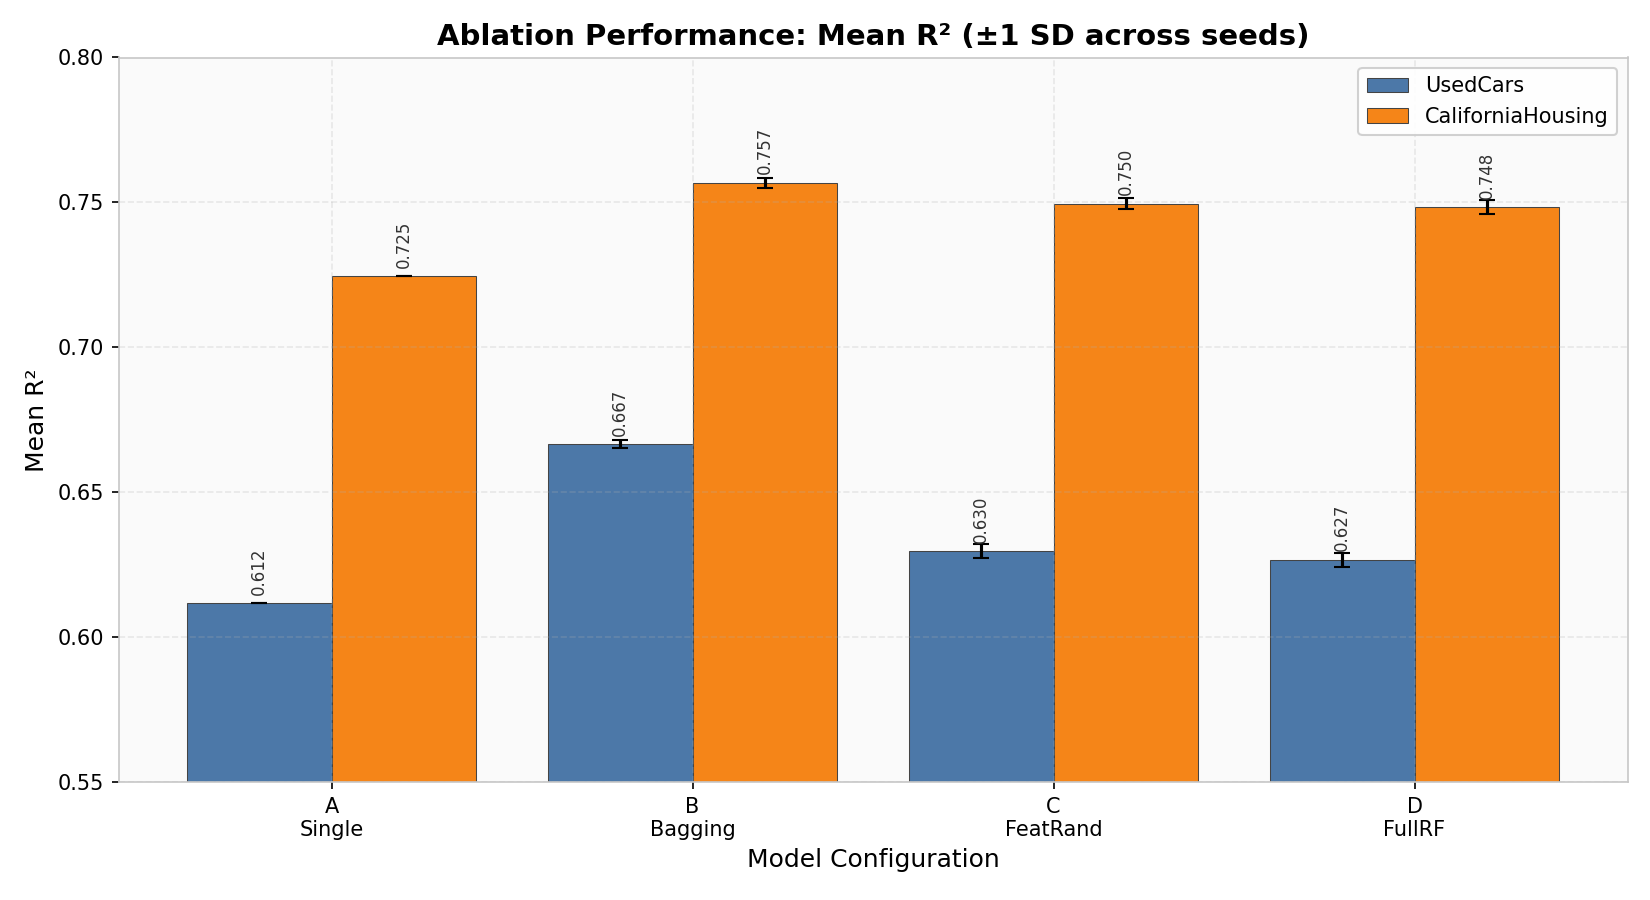

In [4]:
display(Image(filename=str(PLOT_DIR / 'bar_r2.png')))

**What this shows**
- Central predictive performance (mean R²) for each configuration on both datasets.
- Error bars indicate across-seed variability (stability).

**Why it matters**
- This is the primary quality metric for the ablation question: which randomness mechanism helps generalization most.

**Report-ready interpretation**
- "Bagging-only (B) achieves the strongest average predictive fit on both datasets, while feature-randomized variants (C,D) trade some fit for reduced computational cost."
- "Small error bars indicate that ranking differences are not driven by a single random seed."

## Figure 2 — Mean RMSE with seed variability

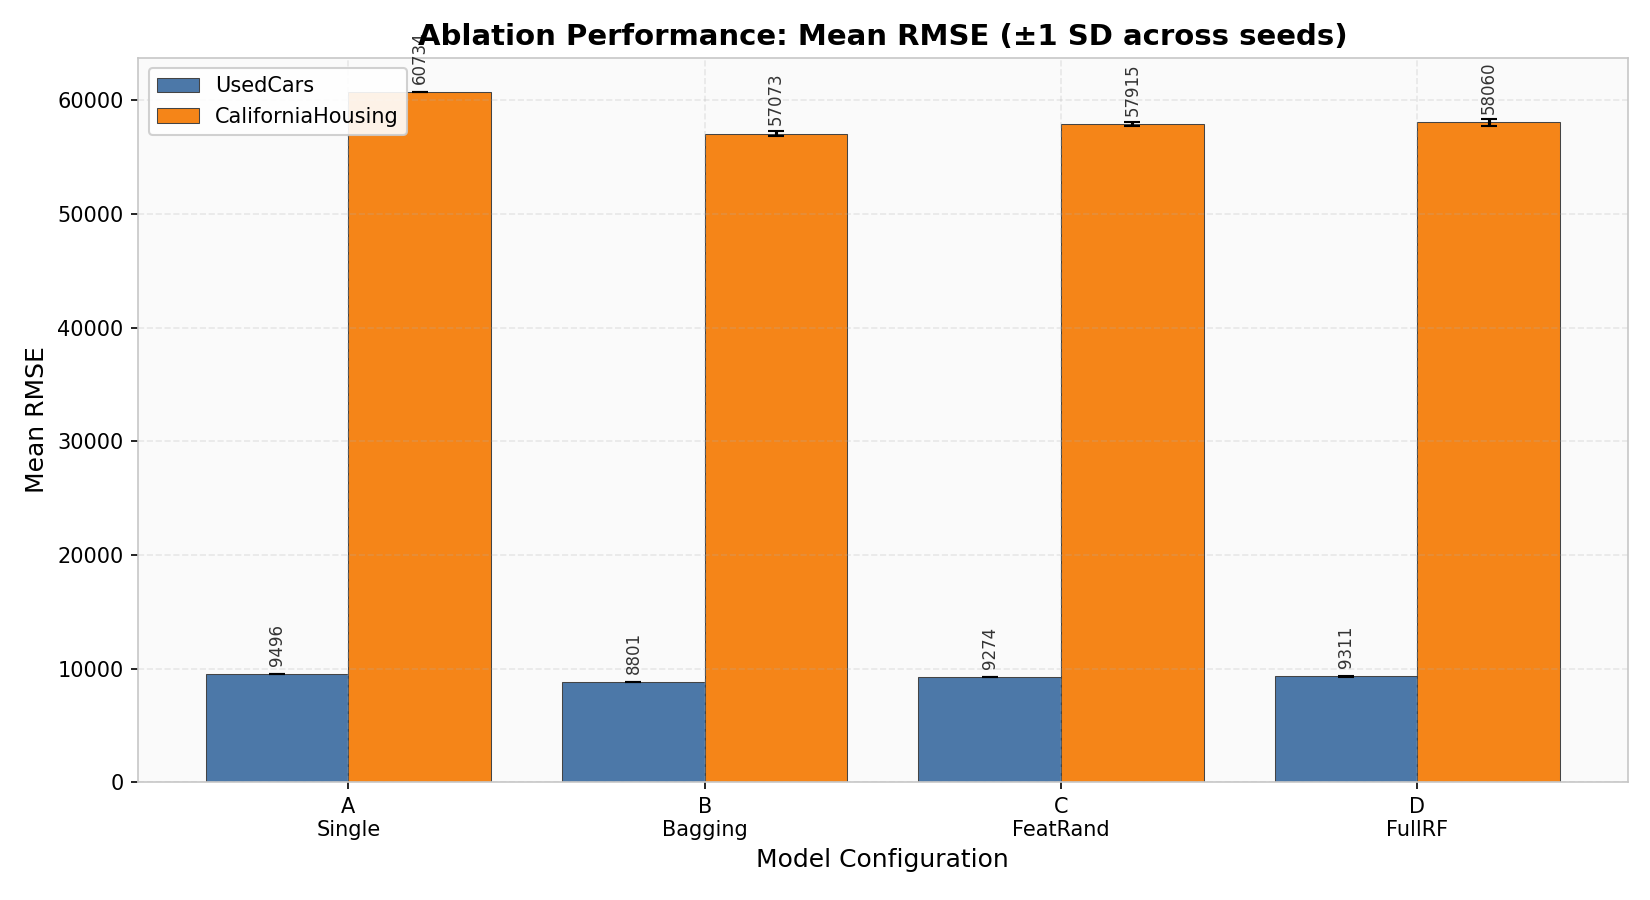

In [5]:
display(Image(filename=str(PLOT_DIR / 'bar_rmse.png')))

**What this shows**
- Absolute prediction error level (lower is better), complementary to R².

**Why it matters**
- Confirms that conclusions are consistent across two metrics, which strengthens claims in the report.

**Report-ready interpretation**
- "The RMSE ranking mirrors the R² ranking, indicating metric-consistent conclusions rather than metric-specific artifacts."
- "B reduces error most, while C and D remain competitive but prioritize efficiency over maximal accuracy."

## Figure 3 — Bias–variance decomposition (overview)

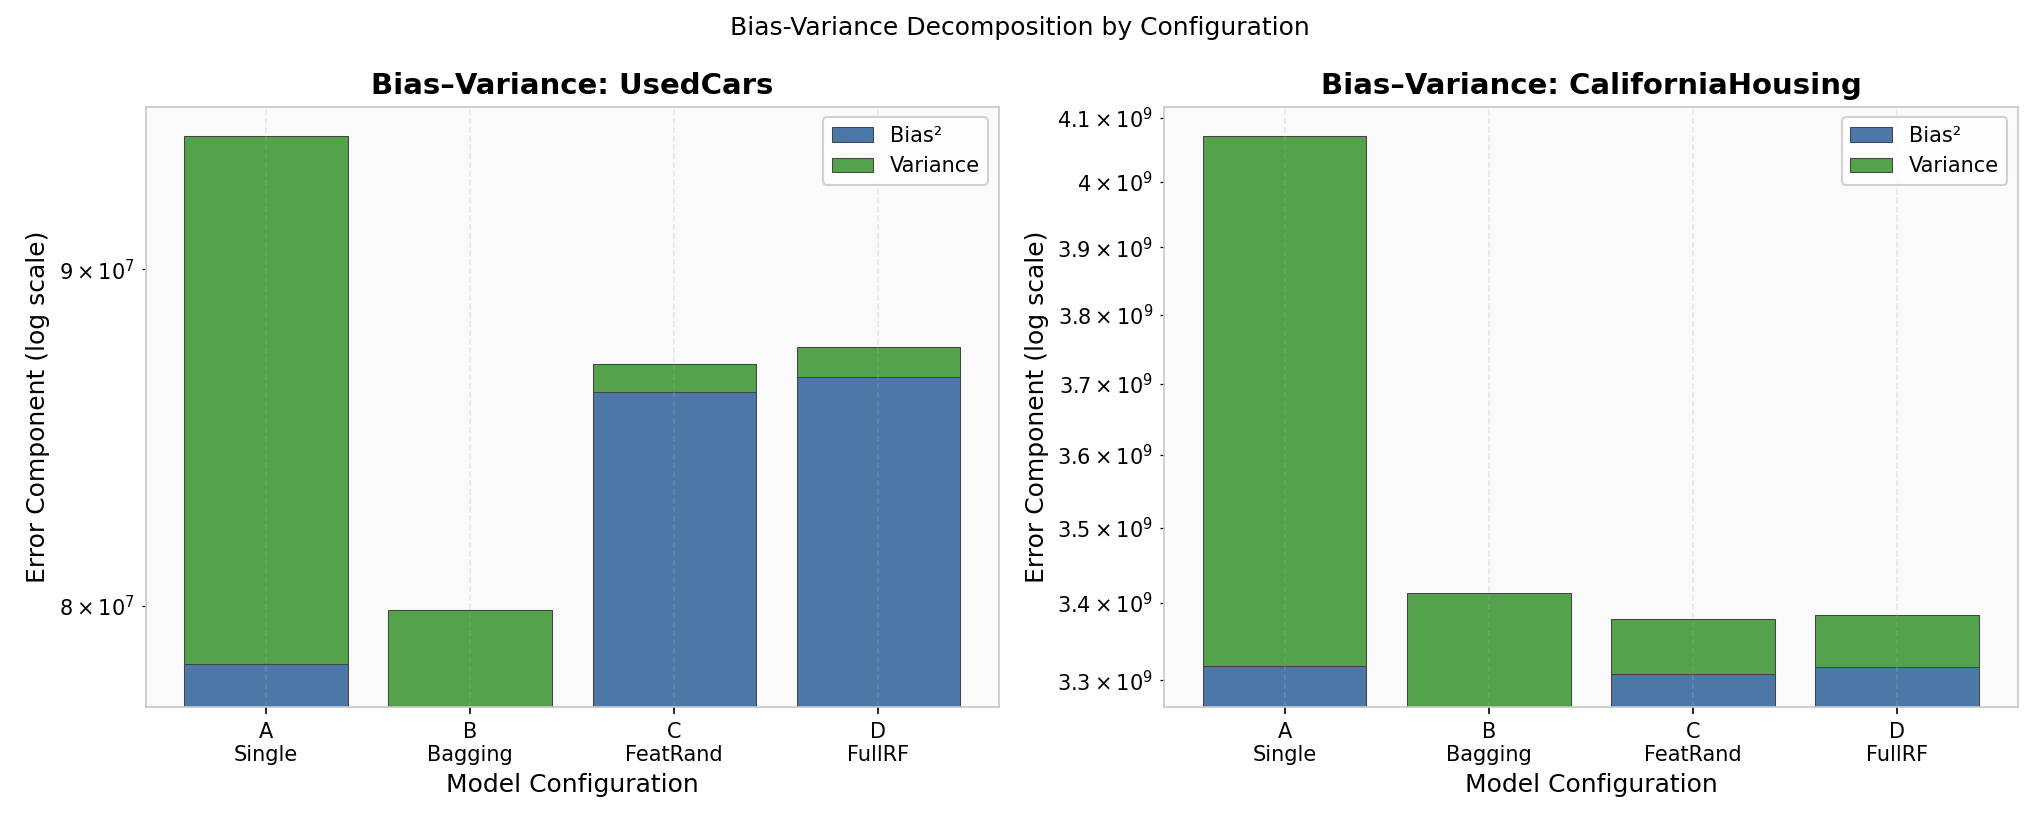

In [6]:
display(Image(filename=str(PLOT_DIR / 'bias_variance_decomposition.png')))

**What this shows**
- Decomposition of prediction error into bias² and variance components.

**Why it matters**
- This figure directly addresses the research question about mechanism-level effects on bias–variance trade-off.

**Important caveat**
- Because this view is stacked and log-scaled, use it for high-level pattern recognition, not fine-grained magnitude comparison.

**Report-ready interpretation**
- "The added randomness in C and D generally suppresses variance but can increase bias, indicating a non-trivial trade-off rather than monotonic improvement."

## Figure 4 — Bias and variance on linear scale (clarity view)

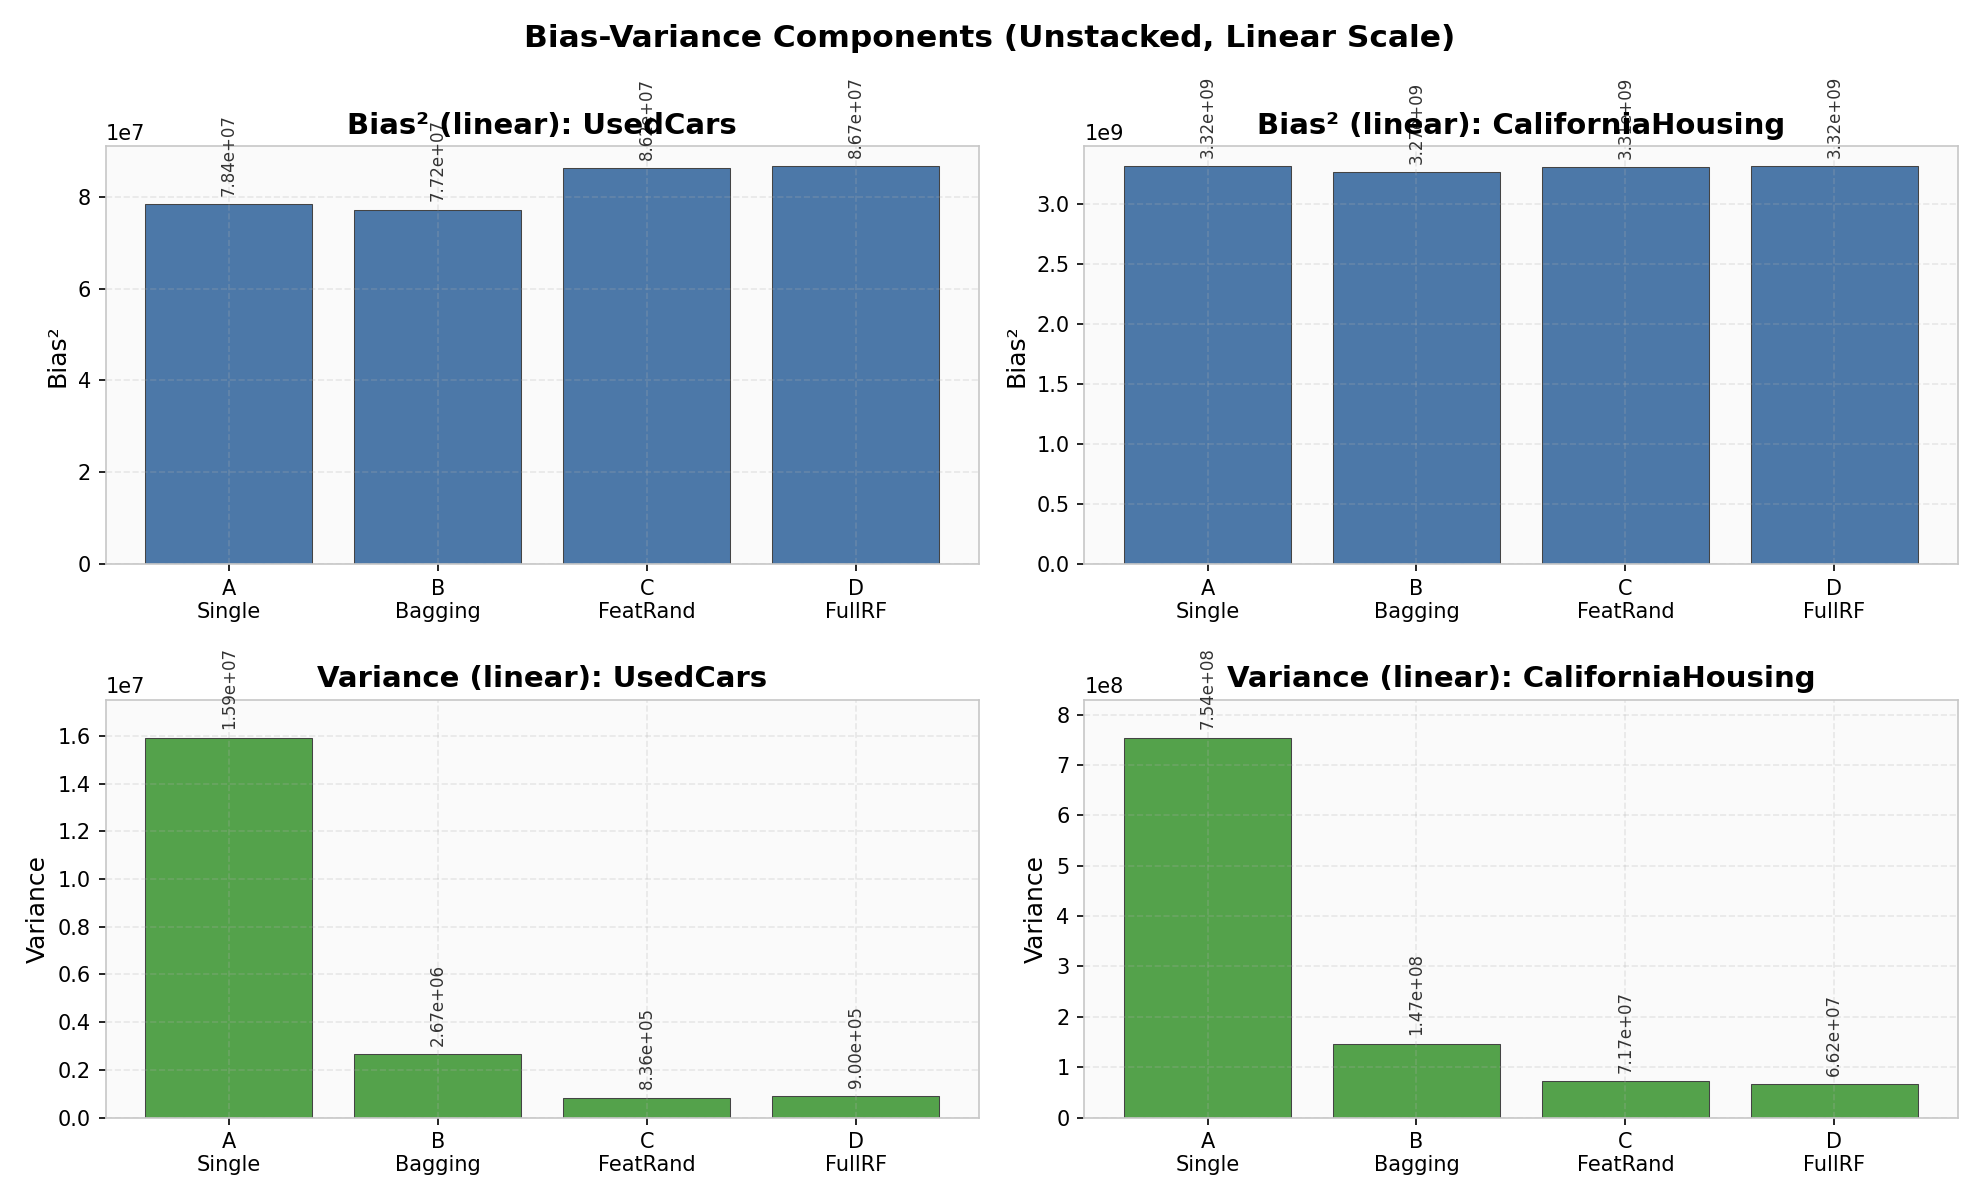

In [7]:
display(Image(filename=str(PLOT_DIR / 'bias_variance_clarity.png')))

**What this shows**
- Same components as Figure 3, but unstacked and with y-axis starting at 0 for intuitive magnitude reading.

**Why it matters**
- Prevents misinterpretation such as "near-zero bias" that can happen in log-stacked displays.

**Report-ready interpretation**
- "The linear-scale component view confirms that B outperforms D primarily through lower bias², despite D achieving lower variance."

## Figure 5 — Relative bias/variance vs baseline A

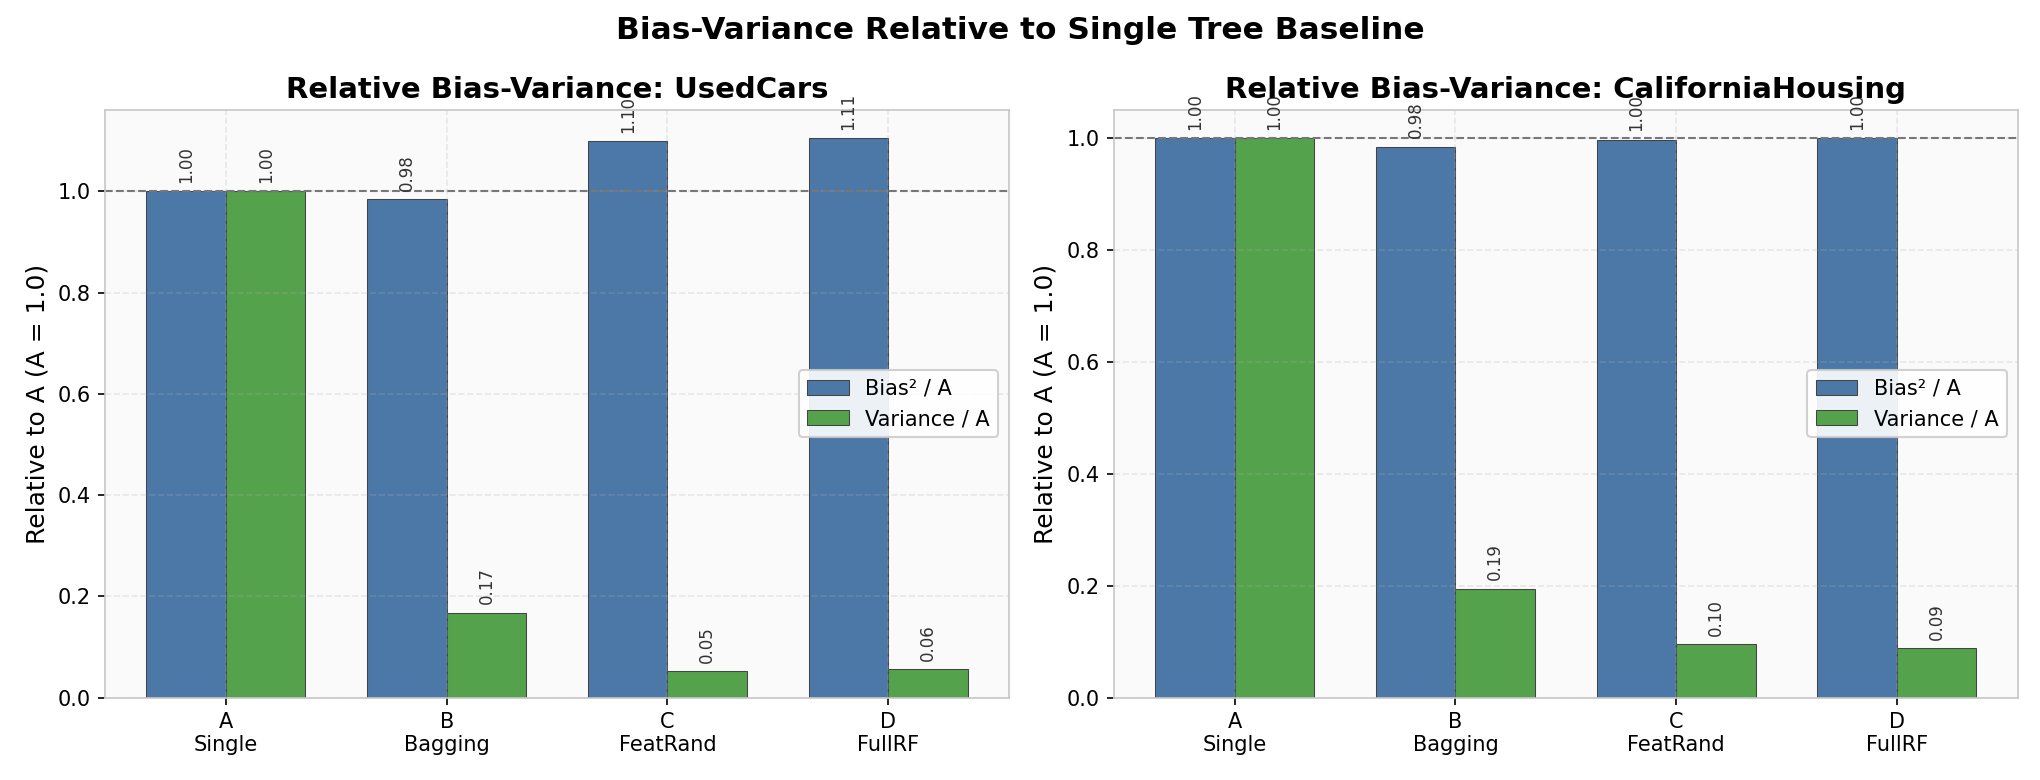

In [8]:
display(Image(filename=str(PLOT_DIR / 'bias_variance_relative_to_A.png')))

**What this shows**
- Each component normalized to A (single tree). Value 1.0 means equal to baseline.

**Why it matters**
- Makes cross-component comparisons readable across different scales and datasets.

**Report-ready interpretation**
- "Relative plots make the mechanism effect explicit: ensembling sharply lowers variance, while feature randomization can increase bias enough to offset some gains."

## Figure 6 — Runtime cost by configuration

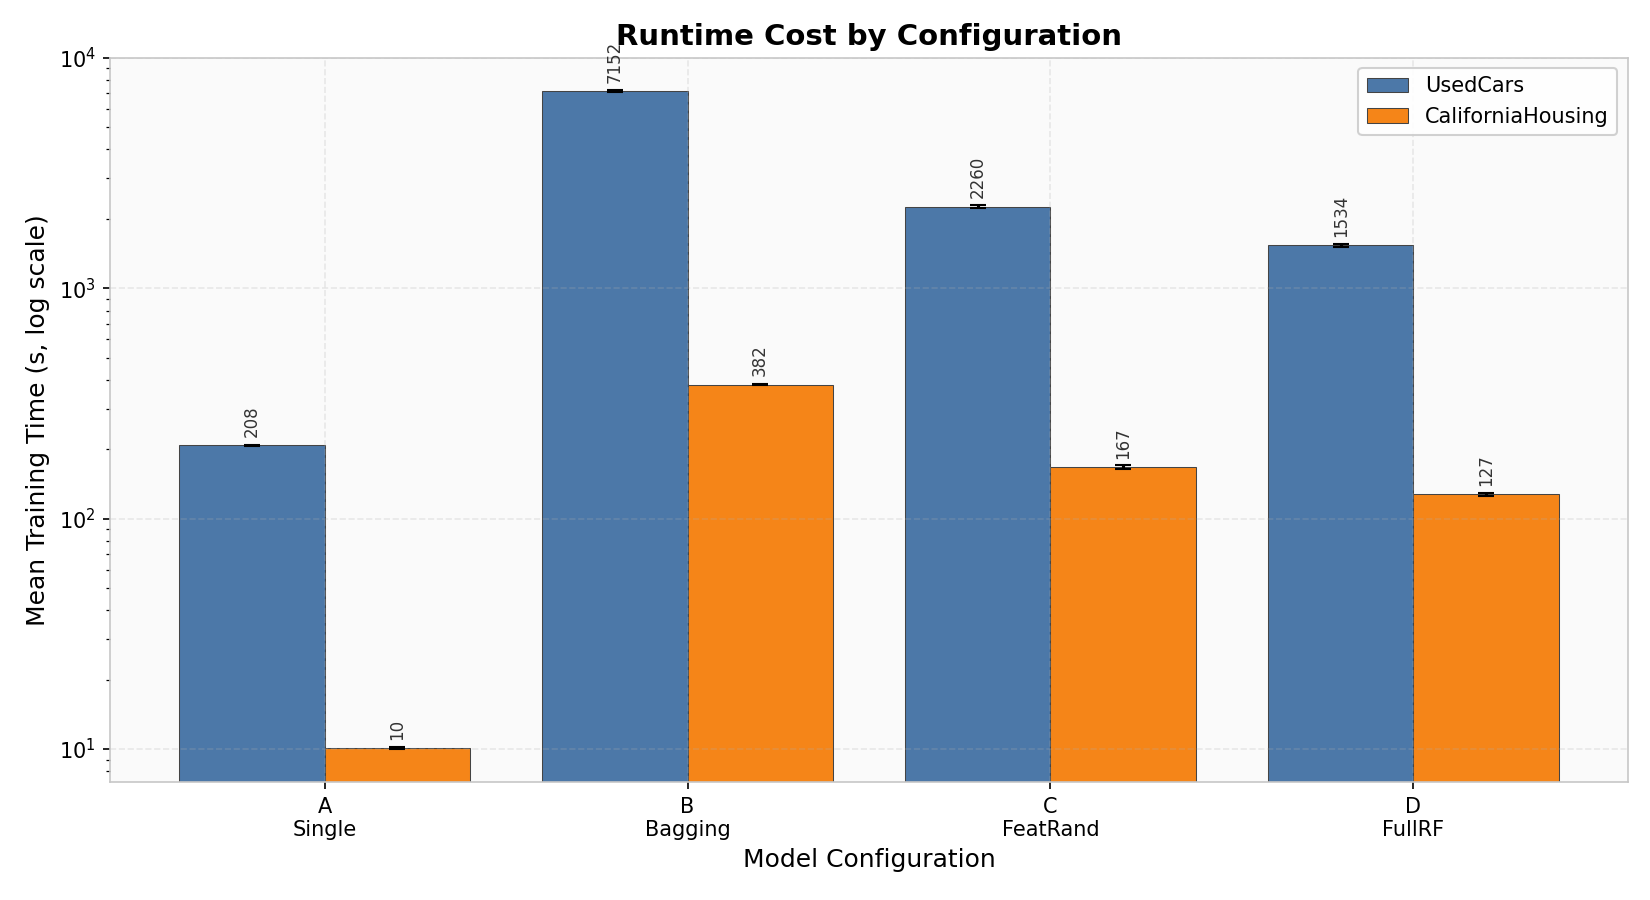

In [9]:
display(Image(filename=str(PLOT_DIR / 'training_time.png')))

**What this shows**
- Mean training time (log scale), with uncertainty across seeds.

**Why it matters**
- Establishes practical cost of each mechanism, enabling a principled accuracy–efficiency discussion.

**Report-ready interpretation**
- "B offers strongest predictive quality but with substantially higher training cost; C and D provide large efficiency gains with moderate accuracy loss."

## Figure 7 — Accuracy–runtime frontier

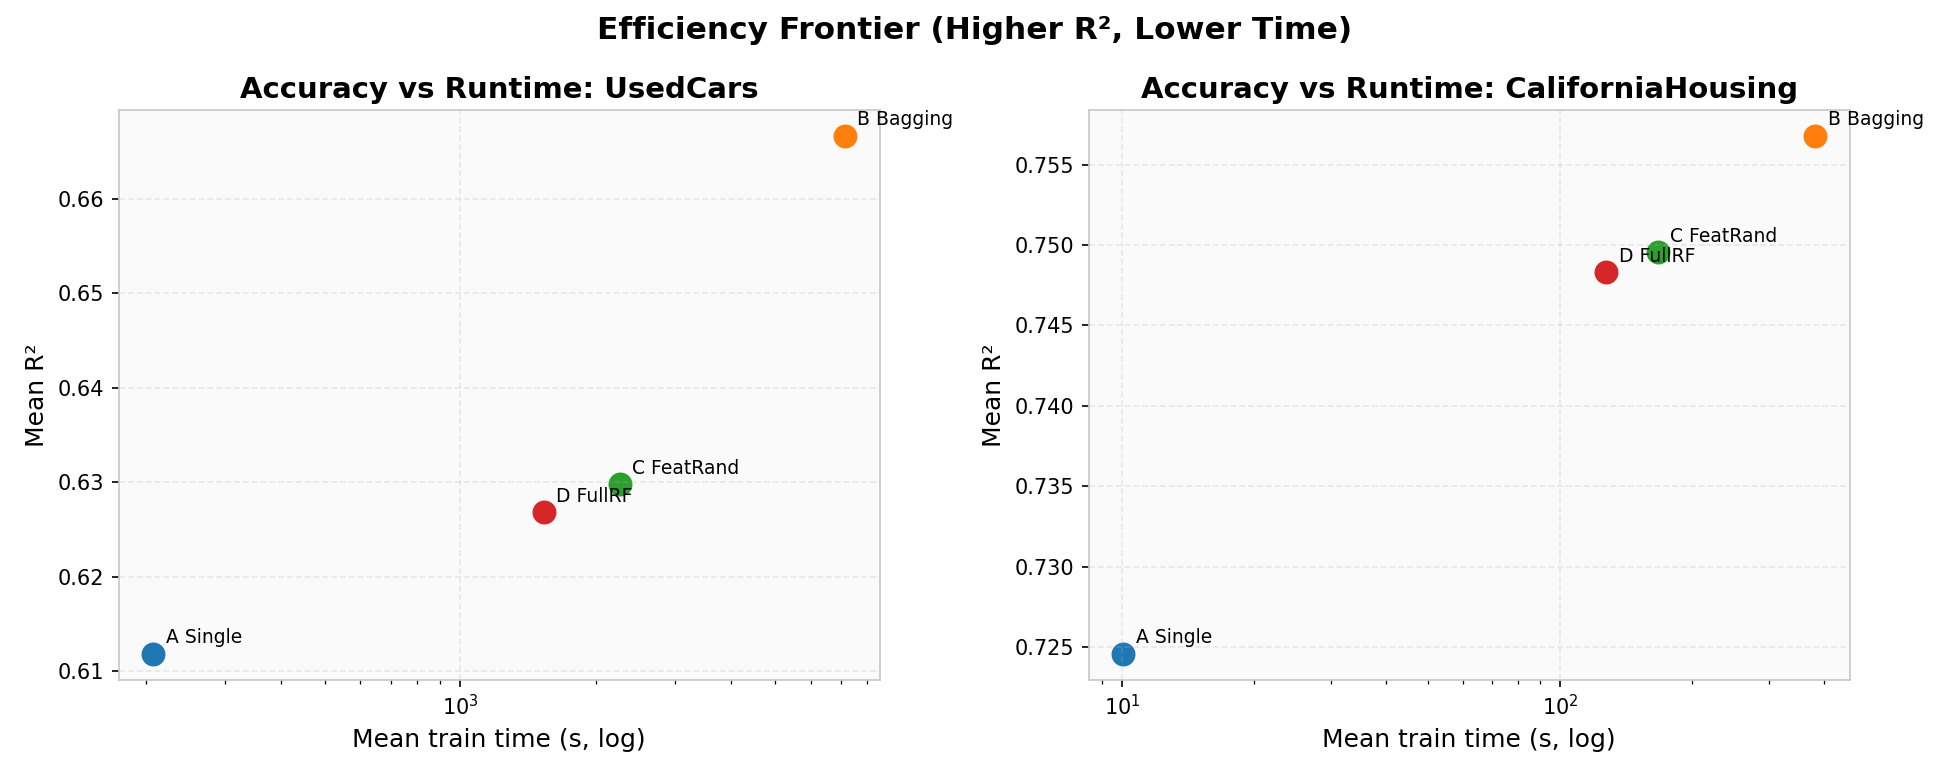

In [10]:
display(Image(filename=str(PLOT_DIR / 'efficiency_frontier.png')))

**What this shows**
- Pareto-like view: better models are toward top-left (higher R², lower time).

**Why it matters**
- Helps justify model selection under compute constraints, not just pure accuracy.

**Report-ready interpretation**
- "B is accuracy-optimal in this experiment, while D is efficiency-optimal among ensemble variants; C lies in between as a compromise point."

## Figure 8 — Seed stability (boxplots)

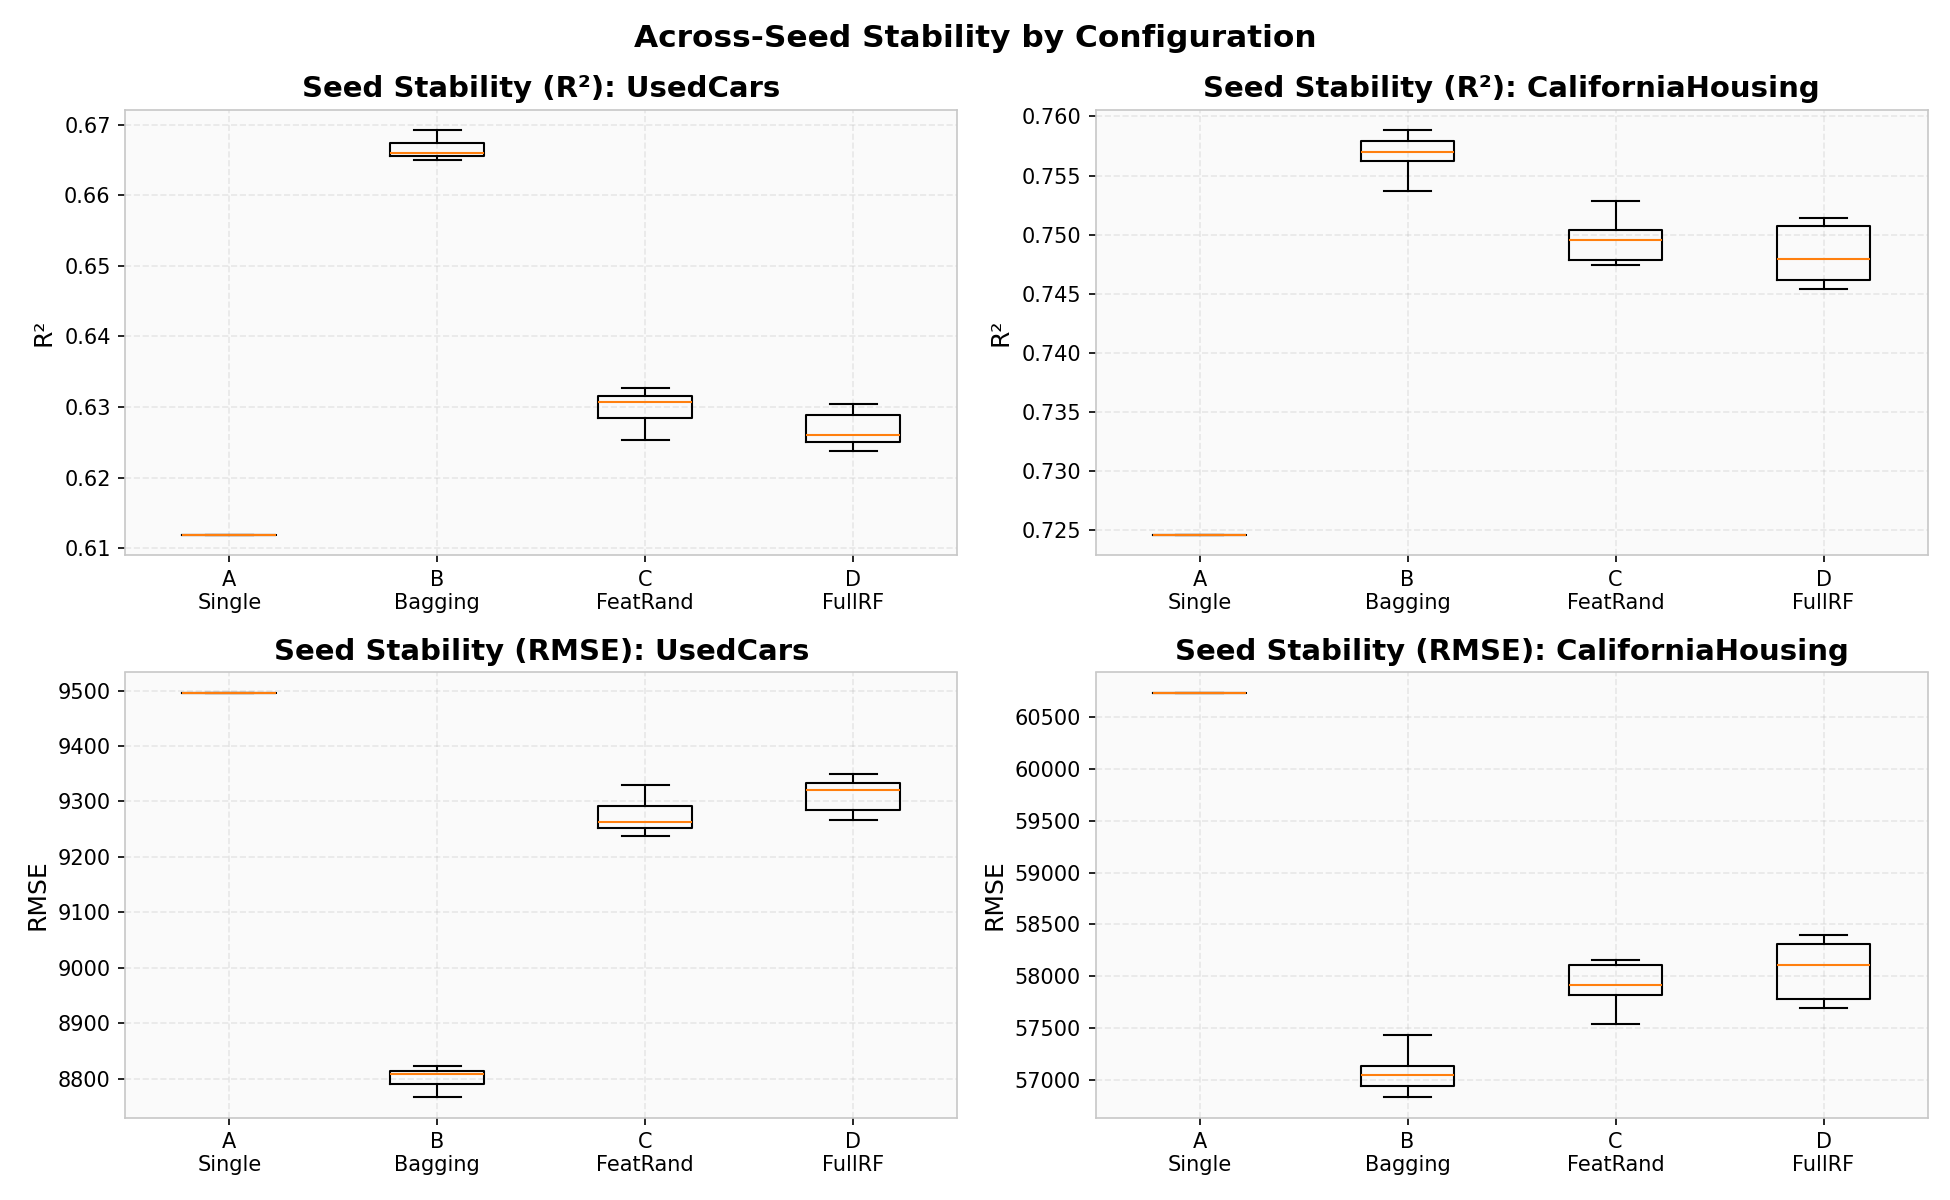

In [11]:
display(Image(filename=str(PLOT_DIR / 'seed_stability.png')))

**How to read the boxplot elements**
- Orange horizontal line: median seed outcome.
- Box: interquartile range (25th to 75th percentile).
- Whiskers: typical spread beyond the box (up to 1.5×IQR).

**Why it matters**
- Demonstrates whether observed ranking is robust to randomness.

**Report-ready interpretation**
- "Across-seed spread is small relative to between-configuration differences, supporting the robustness of the observed ranking."

## Figure 9 — Seed-wise deltas relative to Bagging

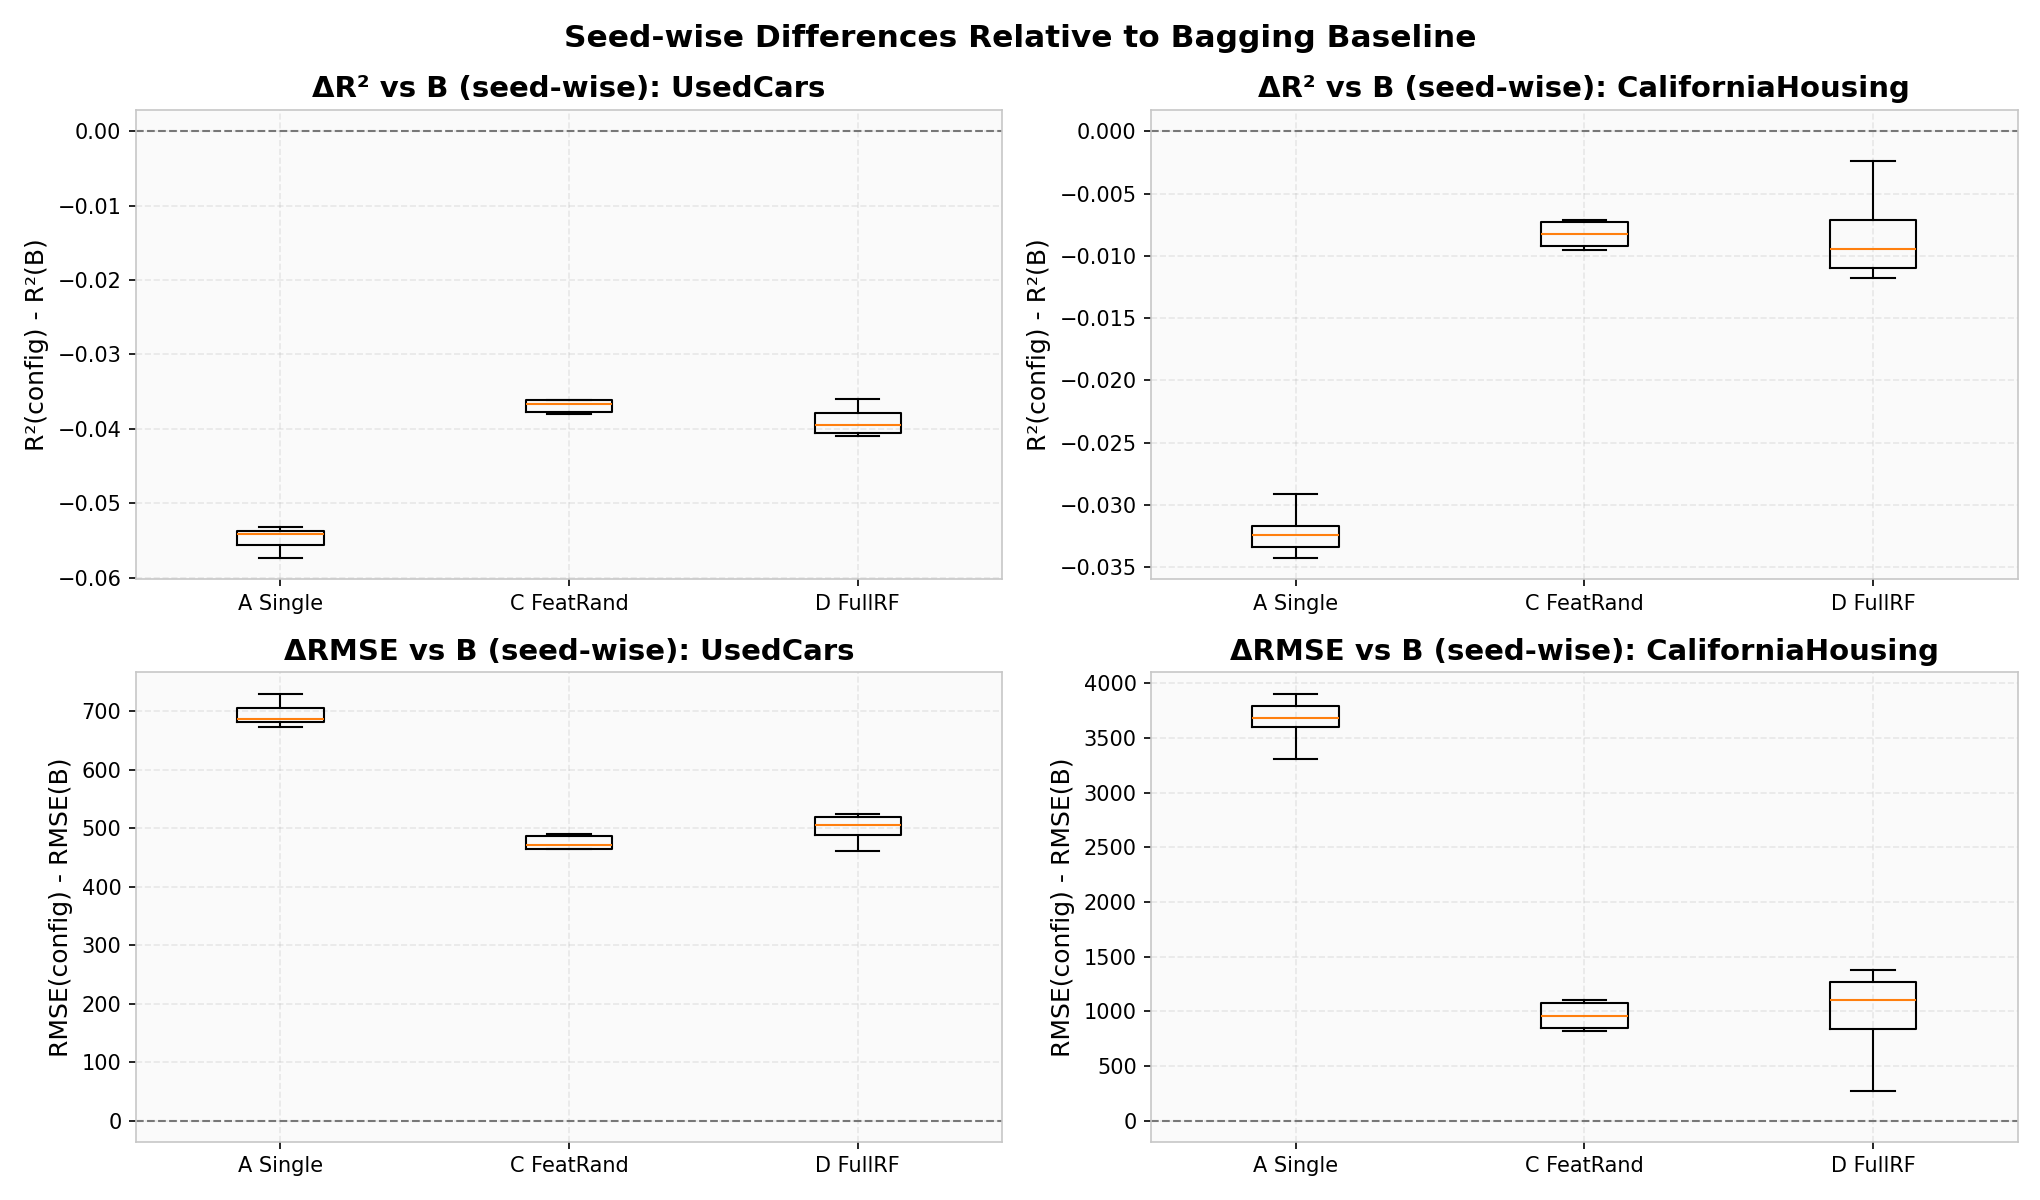

In [12]:
display(Image(filename=str(PLOT_DIR / 'seedwise_delta_vs_bagging.png')))

**What this shows**
- Direct seed-by-seed differences vs B.
- For R²: values below zero imply underperforming B.
- For RMSE: values above zero imply worse error than B.

**Why it matters**
- Converts ranking into effect-size language, which is stronger for argumentation.

**Report-ready interpretation**
- "The distributions remain mostly on the unfavorable side of zero for C and D relative to B, indicating the B advantage is systematic rather than seed-specific."

## Figure 10 — Normalized multi-objective summary

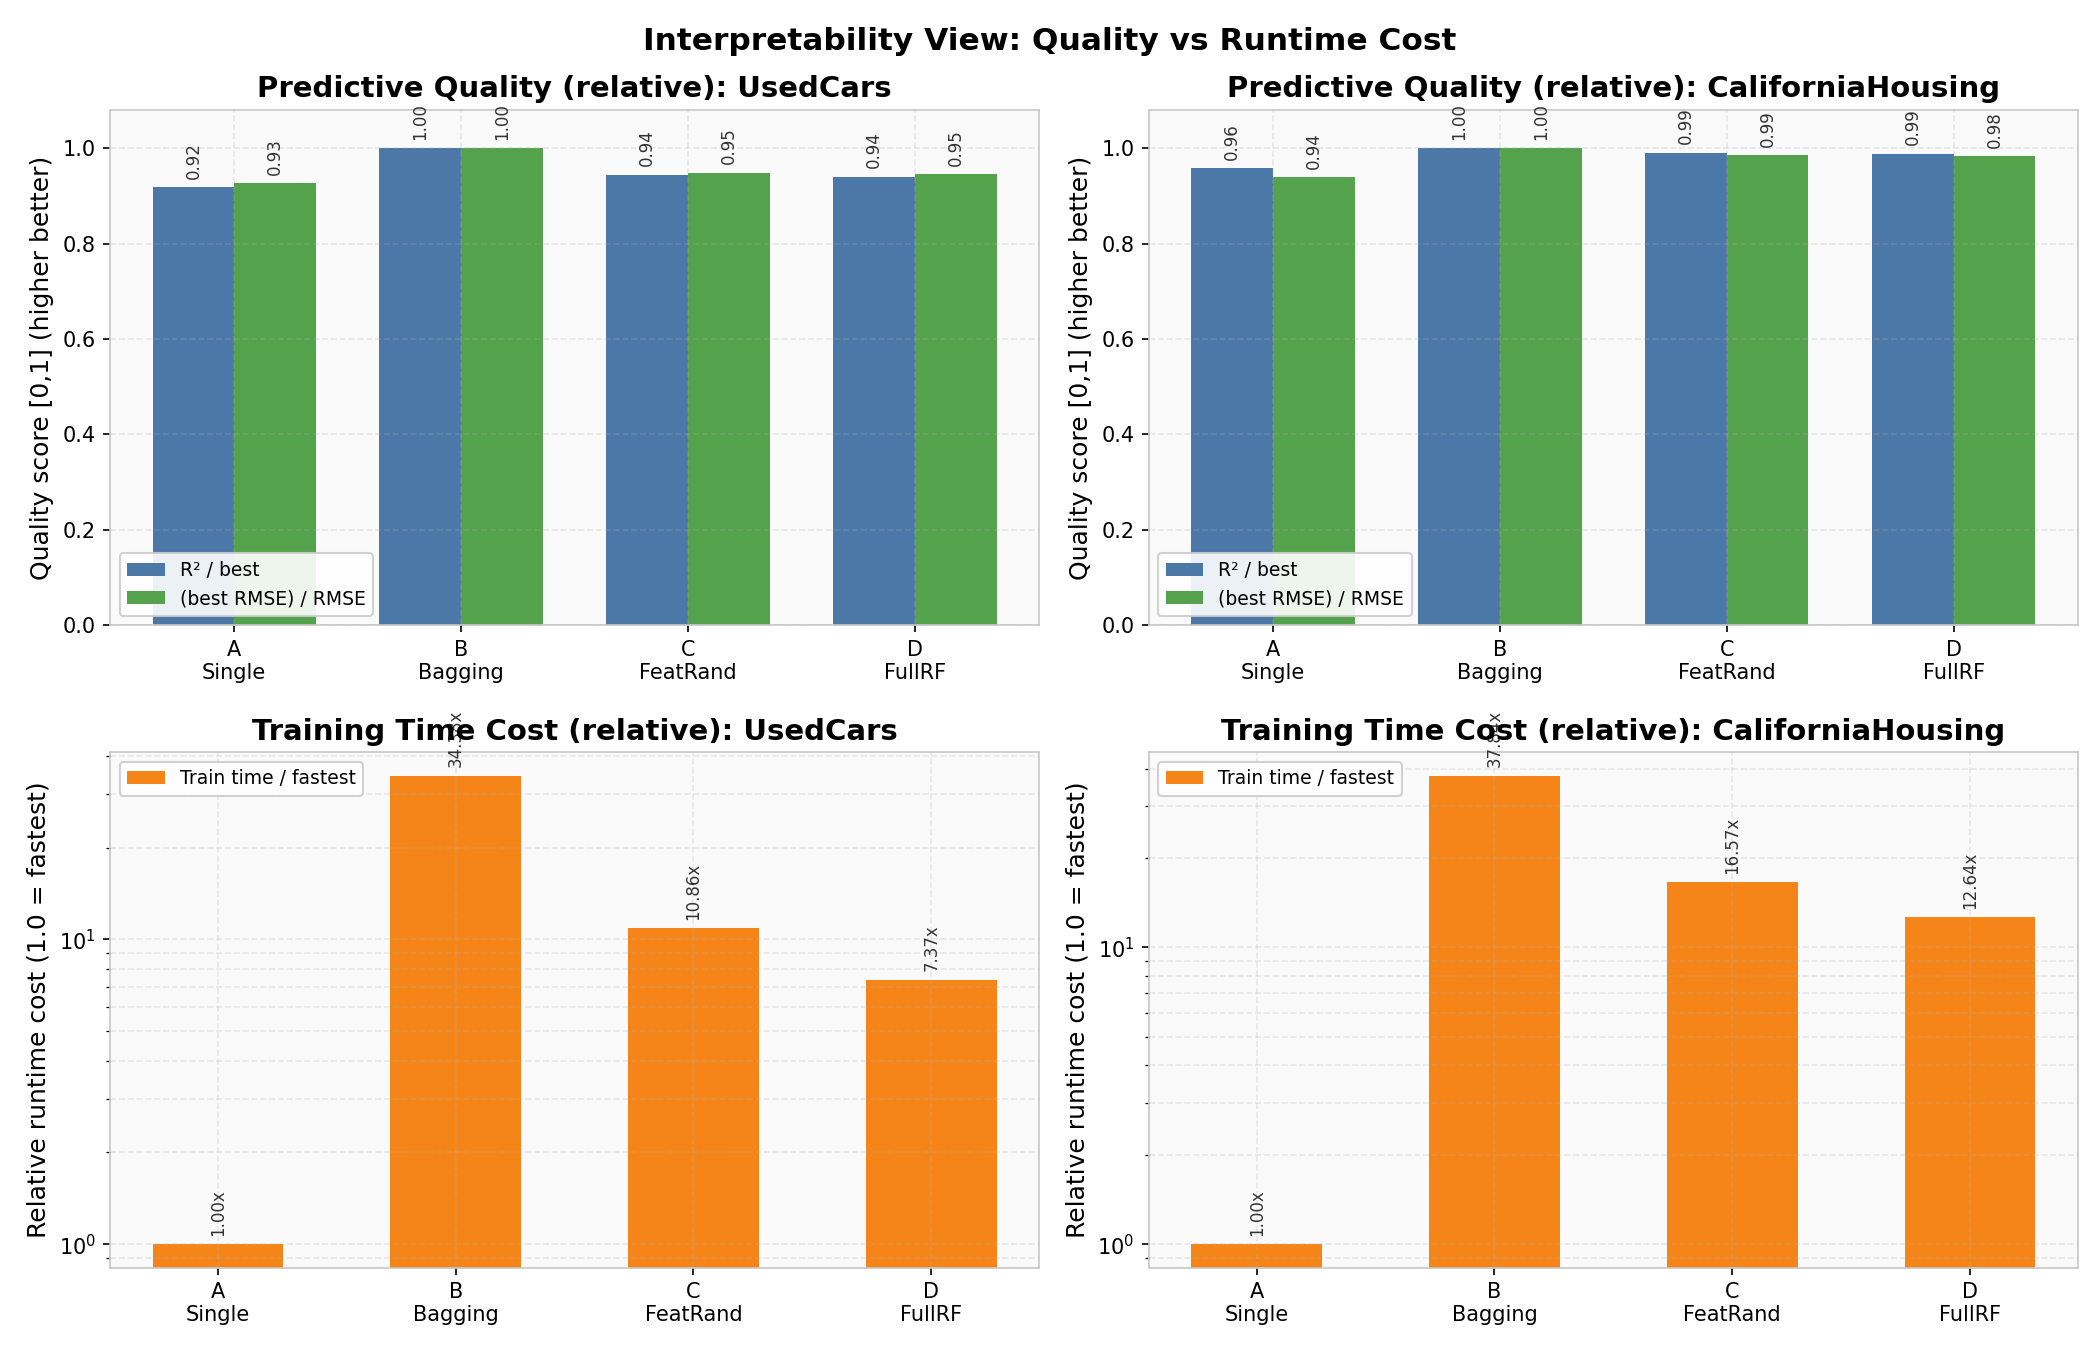

In [15]:
display(Image(filename=str(PLOT_DIR / 'normalized_summary.png')))

**What this shows**
- The top row reports predictive quality as relative-to-best scores (`R² / best`, `(best RMSE) / RMSE`), where higher is better.
- The bottom row reports runtime as relative cost (`train time / fastest`), where `1.0x` is fastest and larger values are slower.

**Why it matters**
- This separates quality and computational cost explicitly, avoiding the common misread that can happen when runtime is inverted into a single "goodness" scale.
- It supports defensible model selection by making trade-offs visible rather than hiding them in one aggregate score.

**Report-ready interpretation**
- "B is the strongest configuration on predictive quality, while C and D reduce computational cost relative to B but do not match its error performance."
- "Presenting runtime as relative cost clarifies that faster configurations are not necessarily more accurate, and that no single model dominates all criteria."

## Suggested final figure set for the report

If space is limited, prioritize:
1. `bar_r2.png` (primary quality metric)
2. `bias_variance_clarity.png` (direct mechanism interpretation)
3. `training_time.png` or `efficiency_frontier.png` (practical trade-off)
4. `seed_stability.png` (robustness)

This combination supports strong scores on: clear presentation, statistical evaluation, and interpretation quality.